# ManOxCo PI-1 — Analytical Workbook
**Oxygen Reliability Transformation Program**

This notebook analyses the ManOxCo Gold-layer data to produce:
- Dry-out risk assessment per hospital
- Plant production and storage trends
- Financial margin analysis
- Maintenance scheduling recommendations
- 18-month operational forecast

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

GOLD = '../data/gold'

prod   = pd.read_parquet(f'{GOLD}/fact_production.parquet')
deliv  = pd.read_parquet(f'{GOLD}/fact_delivery.parquet')
cons   = pd.read_parquet(f'{GOLD}/fact_consumption.parquet')
risk   = pd.read_parquet(f'{GOLD}/mart_dryout_risk.parquet')
fin    = pd.read_parquet(f'{GOLD}/mart_financial.parquet')
plants = pd.read_parquet(f'{GOLD}/dim_plant.parquet')
hosp   = pd.read_parquet(f'{GOLD}/dim_hospital.parquet')

for df in [prod, deliv, cons, risk]:
    df['date'] = pd.to_datetime(df['date'])

print('Data loaded.')
print(f'  Production rows:  {len(prod):,}')
print(f'  Delivery rows:    {len(deliv):,}')
print(f'  Consumption rows: {len(cons):,}')
print(f'  Risk rows:        {len(risk):,}')

Data loaded.
  Production rows:  3,655
  Delivery rows:    1,222
  Consumption rows: 17,959
  Risk rows:        17,959


## 1. Dry-Out Risk Dashboard

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/docs/fig_dryout_risk.png'

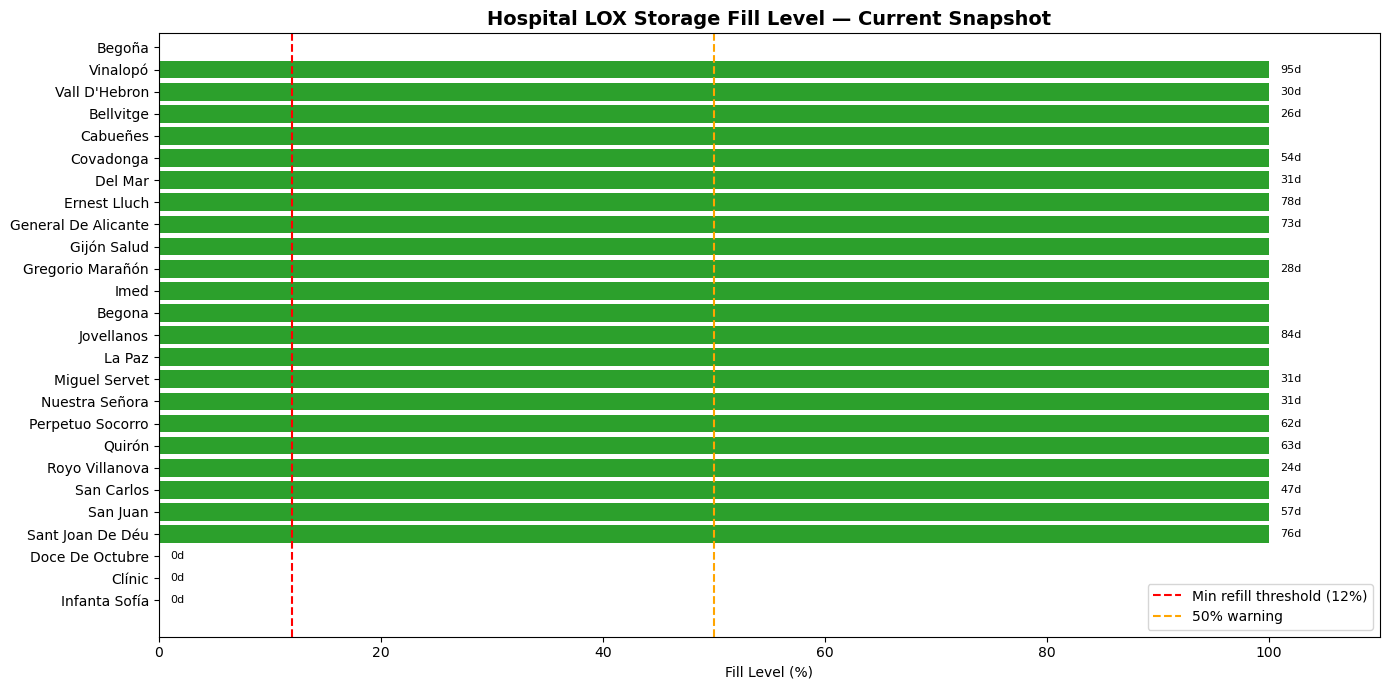

In [2]:
# Latest risk snapshot per hospital
latest_risk = (
    risk.sort_values('date')
    .groupby('hospital_name')
    .last()
    .reset_index()
    [['hospital_name','hospital_city','fill_pct','risk_level','days_to_dryout','estimated_storage','storage_capacity_tons']]
    .sort_values('fill_pct')
)

fig, ax = plt.subplots(figsize=(14, 7))
colors = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#ffdd44', 'LOW': '#2ca02c'}
bar_colors = [colors.get(r, '#aec7e8') for r in latest_risk['risk_level']]

bars = ax.barh(latest_risk['hospital_name'], latest_risk['fill_pct'] * 100, color=bar_colors)
ax.axvline(12, color='red', linestyle='--', linewidth=1.5, label='Min refill threshold (12%)')
ax.axvline(50, color='orange', linestyle='--', linewidth=1.5, label='50% warning')
ax.set_xlabel('Fill Level (%)')
ax.set_title('Hospital LOX Storage Fill Level — Current Snapshot', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(0, 110)

# Annotate days to dry-out
for i, (_, row) in enumerate(latest_risk.iterrows()):
    dtd = f"{row['days_to_dryout']:.0f}d" if row['days_to_dryout'] < 100 else ''
    ax.text(row['fill_pct']*100 + 1, i, dtd, va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../docs/fig_dryout_risk.png', dpi=150, bbox_inches='tight')
plt.show()

critical = latest_risk[latest_risk['risk_level']=='CRITICAL']
print(f"\n⚠️  CRITICAL hospitals: {len(critical)}")
print(critical[['hospital_name','hospital_city','fill_pct','days_to_dryout']].to_string(index=False))

## 2. Production Trends by Plant

In [ ]:
monthly_prod = (
    prod
    .assign(year_month=lambda d: d['date'].dt.to_period('M'))
    .groupby(['year_month','plant'])
    ['production_tons'].sum()
    .reset_index()
)
monthly_prod['year_month_dt'] = monthly_prod['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
plant_names = monthly_prod['plant'].unique()

for ax, plant in zip(axes.flat, plant_names):
    sub = monthly_prod[monthly_prod['plant'] == plant]
    ax.fill_between(sub['year_month_dt'], sub['production_tons'], alpha=0.4)
    ax.plot(sub['year_month_dt'], sub['production_tons'], linewidth=2)
    ax.set_title(plant)
    ax.set_ylabel('Tons')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
    ax.tick_params(axis='x', rotation=30)

for ax in axes.flat[len(plant_names):]:
    ax.set_visible(False)

fig.suptitle('Monthly LOX Production by Plant (2024–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_production_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Financial Margin Analysis

In [ ]:
fin['year_month_dt'] = pd.to_datetime(fin['year_month'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Waterfall: total monthly revenue vs cost vs margin
monthly_total = fin.groupby('year_month_dt')[['total_revenue','total_cost','gross_margin']].sum()
ax1.bar(monthly_total.index, monthly_total['total_revenue'], label='Revenue', alpha=0.8, color='#2ca02c')
ax1.bar(monthly_total.index, monthly_total['total_cost'],    label='Cost',    alpha=0.8, color='#d62728', bottom=0)
ax1.plot(monthly_total.index, monthly_total['gross_margin'], label='Margin',  color='navy', linewidth=2, marker='o')
ax1.set_title('Monthly Revenue, Cost, and Gross Margin', fontweight='bold')
ax1.set_ylabel('EUR (€)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
ax1.tick_params(axis='x', rotation=30)

# Margin % by plant
plant_margin = fin.groupby('plant').agg(
    total_revenue=('total_revenue','sum'),
    total_cost=('total_cost','sum'),
).reset_index()
plant_margin['margin_pct'] = (plant_margin['total_revenue'] - plant_margin['total_cost']) / plant_margin['total_revenue'] * 100
bars = ax2.bar(plant_margin['plant'], plant_margin['margin_pct'],
               color=['#2ca02c' if v > 0 else '#d62728' for v in plant_margin['margin_pct']])
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Cumulative Gross Margin % by Plant', fontweight='bold')
ax2.set_ylabel('Margin (%)')
ax2.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, plant_margin['margin_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/fig_financial_margin.png', dpi=150, bbox_inches='tight')
plt.show()

print(plant_margin[['plant','total_revenue','total_cost','margin_pct']].to_string(index=False))

## 4. Risk Evolution Over Time — Top 5 Most Critical Hospitals

In [ ]:
# Find top 5 hospitals by number of CRITICAL days
critical_count = (
    risk[risk['risk_level']=='CRITICAL']
    .groupby('hospital_name').size()
    .nlargest(5).index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 6))
for hospital in critical_count:
    sub = risk[risk['hospital_name']==hospital].sort_values('date')
    ax.plot(sub['date'], sub['fill_pct']*100, label=hospital, linewidth=1.5)

ax.axhline(12, color='red', linestyle='--', linewidth=1.5, label='Critical threshold (12%)')
ax.fill_between([risk['date'].min(), risk['date'].max()], 0, 12, alpha=0.05, color='red')
ax.set_title('LOX Fill Level Over Time — Top 5 Highest-Risk Hospitals', fontweight='bold')
ax.set_ylabel('Fill Level (%)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../docs/fig_risk_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 18-Month Demand Forecast (Simple Trend Projection)

In [ ]:
from datetime import timedelta

# Aggregate total daily consumption
total_cons = cons.groupby('date')['daily_consumption_tons'].sum().reset_index()
total_cons = total_cons.sort_values('date')
total_cons['days_from_start'] = (total_cons['date'] - total_cons['date'].min()).dt.days

# Linear fit
coeffs = np.polyfit(total_cons['days_from_start'], total_cons['daily_consumption_tons'], 1)
poly = np.poly1d(coeffs)

last_date = total_cons['date'].max()
last_day  = total_cons['days_from_start'].max()
future_days = pd.date_range(last_date + timedelta(days=1), periods=548)  # 18 months
future_x = np.arange(last_day + 1, last_day + 549)
forecast = poly(future_x)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(total_cons['date'], total_cons['daily_consumption_tons'],
        label='Historical', color='steelblue', linewidth=1, alpha=0.8)
ax.plot(future_days, forecast,
        label='18-Month Forecast', color='darkorange', linewidth=2, linestyle='--')
ax.fill_between(future_days, forecast * 0.9, forecast * 1.1,
                alpha=0.15, color='darkorange', label='±10% confidence band')
ax.set_title('Total Daily LOX Consumption — Historical + 18-Month Forecast', fontweight='bold')
ax.set_ylabel('Tons / day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../docs/fig_demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

avg_today = total_cons['daily_consumption_tons'].tail(30).mean()
avg_18m   = forecast[-30:].mean()
print(f'Current avg daily consumption:      {avg_today:.3f} tons/day')
print(f'Projected avg in 18 months:         {avg_18m:.3f} tons/day')
print(f'Demand growth:                      {(avg_18m/avg_today - 1)*100:.1f}%')

## 6. Maintenance Window Optimisation

In [ ]:
import matplotlib.patches as mpatches
from datetime import date as dt_date

MAINTENANCE = [
    {'plant': 'Madrid',    'last': '2025-01-01', 'duration': 22, 'interval_y': 2},
    {'plant': 'Barcelona', 'last': '2023-08-01', 'duration': 20, 'interval_y': 2},
    {'plant': 'Zaragoza',  'last': '2023-06-01', 'duration': 15, 'interval_y': 3},
    {'plant': 'Alicante',  'last': '2023-12-01', 'duration': 12, 'interval_y': 3},
    {'plant': 'Gijon',     'last': '2023-10-01', 'duration': 8,  'interval_y': 3},
]

today = pd.Timestamp.now().normalize()
end   = today + pd.DateOffset(months=18)

fig, ax = plt.subplots(figsize=(16, 5))
y_positions = {p['plant']: i for i, p in enumerate(MAINTENANCE)}

for info in MAINTENANCE:
    last  = pd.Timestamp(info['last'])
    nxt   = last + pd.DateOffset(years=info['interval_y'])
    dur   = pd.DateOffset(days=info['duration'])
    y     = y_positions[info['plant']]

    # Last shutdown (historical)
    ax.barh(y, dur.days, left=mdates.date2num(last.to_pydatetime()),
            height=0.4, color='#aec7e8', label='Historical' if y == 0 else '')

    # Next window
    color = 'red' if nxt <= today else ('orange' if nxt <= today + pd.DateOffset(months=3) else '#2ca02c')
    ax.barh(y, dur.days, left=mdates.date2num(nxt.to_pydatetime()),
            height=0.4, color=color, alpha=0.8,
            label='Recommended window' if y == 0 else '')

ax.axvline(mdates.date2num(today.to_pydatetime()), color='black', linewidth=2, label='Today')
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
ax.set_xlim(pd.Timestamp('2023-01-01'), end)
ax.set_title('Plant Maintenance Schedule — Recommended Windows', fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../docs/fig_maintenance_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMaintenance Status:')
for info in MAINTENANCE:
    last = pd.Timestamp(info['last'])
    nxt  = last + pd.DateOffset(years=info['interval_y'])
    days = (nxt - today).days
    status = 'OVERDUE' if days < 0 else ('DUE SOON' if days < 90 else 'OK')
    print(f"  {info['plant']:12s}  next: {nxt.date()}  ({days:+d}d)  [{status}]")